# Guia do funcionamento da Simulação do Blind Quantum Computing
##### O documento tem o objetivo de demostrar o funcionamento da simulação dos protocolos Childs e BFK no BQC.
#### IMPORTANDO AS DEPENDÊNCIAS


In [1]:
import random
from quantumnet.components import Network, Host
from quantumnet.components import ServerNode, ClientNode, RegularNode
from quantumnet.objects import Qubit, Logger

##### É inicializada a rede, com uma topologia de grade, que apresenta 1 servidor (nó verde) e 8 clientes (nós vermelhos).

Hosts inicializados
Canais inicializados
Pares EPRs adicionados


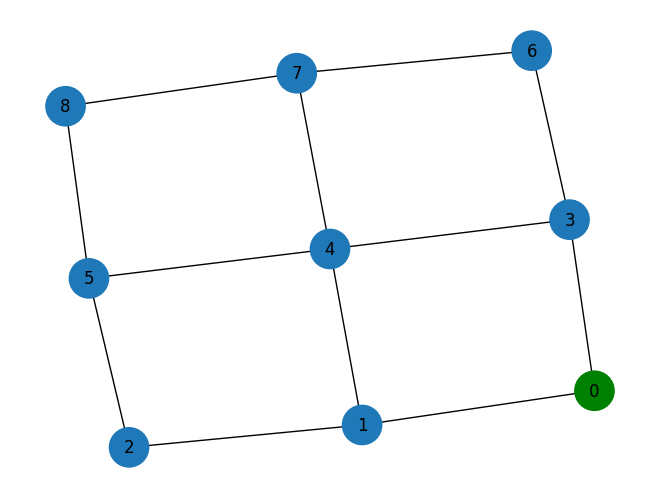

In [2]:
rede = Network()
rede.set_ready_topology('grade',8,3,3)  # Exemplo de uma grade 3x3 com  clientes e 1 servidor
rede.draw()
Logger.activate(Logger)

##### A realização da simulação de uma requesição acontece de forma em que vamos passar uma função para a geração de um circuito aleatório com o número de qubits e número de portas passados como parâmetros e a escolha de um protocolo para executar esse circuito. Além de haver o parâmetro "scenario", que pode ser 1 ou 2, respectivamente, para o cenário normal e cenário da proposta. O protocolo escolhido foi o AC_BQC, Childs, e o cliente é (alice_id).

In [3]:
quantum_circuit, num_qubits, circuit_depth = rede.generate_random_circuit(num_qubits=20, num_gates=20)
rede.application_layer.run_app("AC_BQC", alice_id=6, bob_id=0, num_qubits=10,scenario=1,circuit_depth=circuit_depth)

                   ┌───┐                
 q_0: ─────────────┤ S ├────────────────
              ┌───┐└───┘                
 q_1: ──────■─┤ X ├─────────────────────
            │ └───┘                     
 q_2: ──────┼───────────────────────────
            │                           
 q_3: ──────┼───────────────────────────
            │      ┌───┐                
 q_4: ──────┼──────┤ X ├──X───────────■─
            │      └───┘  │           │ 
 q_5: ──X───┼─────────────┼───────────┼─
        │   │ ┌───┐       │           │ 
 q_6: ──┼───┼─┤ X ├───────X───────────┼─
        │   │ └───┘┌───┐              │ 
 q_7: ──┼───┼──────┤ Y ├──────────────┼─
        │   │      └───┘              │ 
 q_8: ──┼───┼───■─────────────────────┼─
        │   │   │  ┌───┐              │ 
 q_9: ──┼───┼───┼──┤ X ├──■───────────┼─
        │   │   │  └─┬─┘  │  ┌───┐    │ 
q_10: ──┼───┼───┼────■────┼──┤ X ├────┼─
        │   │   │         │  └───┘    │ 
q_11: ──┼───┼───┼─────────┼────X──────┼─
        │   │   

2025-12-11 10:57:03,920: Circuito aleatório gerado com 20 qubits e 20 portas. Instruções sobre o circuito.
2025-12-11 10:57:03,922: Instrução: {'operation': 'y', 'qubits': [15]}
2025-12-11 10:57:03,923: Instrução: {'operation': 'cz', 'qubits': [1, 16]}
2025-12-11 10:57:03,930: Instrução: {'operation': 'swap', 'qubits': [12, 5]}
2025-12-11 10:57:03,931: Instrução: {'operation': 'z', 'qubits': [13]}
2025-12-11 10:57:03,932: Instrução: {'operation': 'cz', 'qubits': [17, 8]}
2025-12-11 10:57:03,934: Instrução: {'operation': 'x', 'qubits': [6]}
2025-12-11 10:57:03,935: Instrução: {'operation': 'cx', 'qubits': [10, 9]}
2025-12-11 10:57:03,935: Instrução: {'operation': 'cx', 'qubits': [9, 12]}
2025-12-11 10:57:03,936: Instrução: {'operation': 'x', 'qubits': [4]}
2025-12-11 10:57:03,936: Instrução: {'operation': 'swap', 'qubits': [15, 11]}
2025-12-11 10:57:03,937: Instrução: {'operation': 't', 'qubits': [19]}
2025-12-11 10:57:03,938: Instrução: {'operation': 'x', 'qubits': [10]}
2025-12-11 10:

##### Nessa função, pode-se coletar a métrica da média da fidelidade dos pares EPRs utilizados na requesição.

In [4]:
rede.application_layer.avg_fidelity_on_applicationlayer()

2025-12-11 10:57:04,110: Nenhuma fidelidade foi registrada na camada de aplicação.


0.0

##### Além de haver uma função para mostrar as fidelidades das rotas.

In [5]:
rede.application_layer.print_route_fidelities()

Nenhuma fidelidade de rota foi registrada.


##### Nesse caso, foi executado o protocolo BFK, com parâmetros como 20 qubits e 20 portas. Além da escolha de um nó como cliente=alice_id.

In [6]:
quantum_circuit, num_qubits, circuit_depth = rede.generate_random_circuit(num_qubits=20, num_gates=20)
rede.application_layer.run_app("BFK_BQC", alice_id=2, bob_id=0, num_qubits=num_qubits,scenario=1,circuit_depth= circuit_depth)

2025-12-11 10:57:04,238: Circuito aleatório gerado com 20 qubits e 20 portas. Instruções sobre o circuito.
2025-12-11 10:57:04,239: Instrução: {'operation': 'cz', 'qubits': [15, 0]}
2025-12-11 10:57:04,239: Instrução: {'operation': 'cz', 'qubits': [17, 2]}
2025-12-11 10:57:04,240: Instrução: {'operation': 'z', 'qubits': [14]}
2025-12-11 10:57:04,241: Instrução: {'operation': 'swap', 'qubits': [14, 16]}
2025-12-11 10:57:04,242: Instrução: {'operation': 'cx', 'qubits': [4, 6]}
2025-12-11 10:57:04,243: Instrução: {'operation': 's', 'qubits': [16]}
2025-12-11 10:57:04,244: Instrução: {'operation': 'y', 'qubits': [13]}
2025-12-11 10:57:04,244: Instrução: {'operation': 'h', 'qubits': [13]}
2025-12-11 10:57:04,245: Instrução: {'operation': 'h', 'qubits': [17]}
2025-12-11 10:57:04,246: Instrução: {'operation': 'x', 'qubits': [11]}
2025-12-11 10:57:04,247: Instrução: {'operation': 'x', 'qubits': [5]}
2025-12-11 10:57:04,248: Instrução: {'operation': 'x', 'qubits': [15]}
2025-12-11 10:57:04,251:

         ┌───┐                     
 q_0: ─■─┤ Y ├─────────────────────
       │ └───┘                     
 q_1: ─┼───────────────────────────
       │                           
 q_2: ─┼───■───────────────────────
       │   │                       
 q_3: ─┼───┼───────────────────────
       │   │                       
 q_4: ─┼───┼────■─────────X────────
       │   │    │  ┌───┐  │        
 q_5: ─┼───┼────┼──┤ X ├──┼────────
       │   │  ┌─┴─┐└───┘  │        
 q_6: ─┼───┼──┤ X ├───────┼────────
       │   │  └───┘       │        
 q_7: ─┼───┼──────────────┼────────
       │   │              │        
 q_8: ─┼───┼──────────────X────────
       │   │                       
 q_9: ─┼───┼──────────────────X────
       │   │                  │    
q_10: ─┼───┼──────────────────┼────
       │   │  ┌───┐           │    
q_11: ─┼───┼──┤ X ├───────────┼────
       │   │  └───┘           │    
q_12: ─┼───┼──────────────────┼──■─
       │   │  ┌───┐┌───┐      │  │ 
q_13: ─┼───┼──┤ Y ├┤ H ├──X─

2025-12-11 10:57:04,305: Qubit 13 adicionado à memória do Host 2.
2025-12-11 10:57:04,306: Qubit 13 criado com fidelidade inicial 0.9672453517814351 e adicionado à memória do Host 2.
2025-12-11 10:57:04,307: Qubit 14 adicionado à memória do Host 2.
2025-12-11 10:57:04,307: Qubit 14 criado com fidelidade inicial 0.9989484204908757 e adicionado à memória do Host 2.
2025-12-11 10:57:04,308: Qubit 15 adicionado à memória do Host 2.
2025-12-11 10:57:04,308: Qubit 15 criado com fidelidade inicial 0.9542640354709554 e adicionado à memória do Host 2.
2025-12-11 10:57:04,309: Qubit 16 adicionado à memória do Host 2.
2025-12-11 10:57:04,310: Qubit 16 criado com fidelidade inicial 0.9976960579688875 e adicionado à memória do Host 2.
2025-12-11 10:57:04,311: Qubit 17 adicionado à memória do Host 2.
2025-12-11 10:57:04,312: Qubit 17 criado com fidelidade inicial 0.9911683087380205 e adicionado à memória do Host 2.
2025-12-11 10:57:04,313: Qubit 18 adicionado à memória do Host 2.
2025-12-11 10:57:04

##### Nessa função, podemos coletar a métrica da média da fidelidade dos pares EPRs utilizados nas duas requesições.

In [7]:
rede.application_layer.avg_fidelity_on_applicationlayer()

2025-12-11 10:57:04,402: A média das fidelidades das rotas é: 0.7402


0.7401522817998677

##### Além de printar as fidelidades das rotas.

In [8]:
rede.application_layer.print_route_fidelities()

Fidelidades das rotas utilizadas:
0.8633
0.7543
0.6029


##### Pode ser coletado os EPRs utilizados na camada de aplicação, consequentemente nas requesições e protocolos.

In [9]:
rede.get_total_useds_eprs()

2025-12-11 10:57:04,439: Eprs usados na camada LinkLayer: 0
2025-12-11 10:57:04,440: Eprs usados na camada NetworkLayer: 0
2025-12-11 10:57:04,441: Eprs usados na camada ApplicationLayer: 26


26